In [ ]:
#### edit3 파일에서 merged_data.csv 저장하기 전에 추가한 파생변수들입니다 윤서님~^^


# 1. 실제 배송 소요 일수
# 소수점 1자리까지 유지 (정확도 향상을 위해)
df_final['delivery_days'] = (df_final['order_delivered_customer_date'] - df_final['order_purchase_timestamp']).dt.total_seconds() / 86400
df_final['delivery_days'] = df_final['delivery_days'].round(1)

# 2. 출고 소요 일수 계산 (order_delivered_carrier_date - order_purchase_timestamp)
df_final['dispatch_days'] = (df_final['order_delivered_carrier_date'] - df_final['order_purchase_timestamp']).dt.total_seconds() / 86400
df_final['dispatch_days'] = df_final['dispatch_days'].round(1)

# 3. 배송 지연 일수 (실제 도착일 - 예상 도착일)
# 양수(+)면 지연됨, 음수(-)면 예상보다 일찍 도착함
# 윤서님 순서랑 바꾼 이유는, 지연 일수가 양수로 표현이 되어야 나중에 그래프나 분석할 때 직관적일 것 같아서 바꿨습니다
df_final['delay_days'] = (df_final['order_delivered_customer_date'] - df_final['order_estimated_delivery_date']).dt.total_seconds() / 86400
df_final['delay_days'] = df_final['delay_days'].round(1)

# 4. 분석을 매우 쉽게 만들어줄 명확한 파생변수: 지연 여부 (0 또는 1)
# 지연일수가 0보다 크면 1(지연), 아니면 0(정상/조기배송)
df_final['is_delayed'] = (df_final['delay_days'] > 0).astype(int)

In [10]:
# 데이터 처리 및 분석
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg
import scikit_posthocs as sp

# 머신러닝 
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import accuracy_score, classification_report, r2_score, mean_squared_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from xgboost import XGBClassifier, XGBRegressor

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 시드 설정
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [11]:
df = pd.read_csv('./data/merged_data.csv')

print("="*60)
print("데이터 로드 완료!")
print("="*60)
print(f"\ndf: {df.shape}")

데이터 로드 완료!

df: (96432, 22)


In [12]:
df

,order_id,customer_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state,total_items_count,product_id,seller_id,shipping_limit_date,price,freight_value,review_score,review_comment_title,review_comment_message,product_category_name_english,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",housewares,maua,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,barreiras,BA,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,4.0,Muito boa a loja,Muito bom o produto.,perfumery,belo horizonte,SP
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,5.0,NaN,NaN,auto,guariba,SP
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,5.0,NaN,O produto foi exatamente o que eu esperava e e...,pet_shop,belo horizonte,MG
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,5.0,NaN,NaN,stationery,mogi das cruzes,SP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96427,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00,6359f309b166b0196dbf7ad2ac62bb5a,sao jose dos campos,SP,1,ac35486adb7b02598c182c2ff2e05254,e24fc9fcd865784fb25705606fe3dfe7,2017-03-15 09:54:05,72.00,13.08,5.0,NaN,NaN,health_beauty,braganca paulista,SP
96428,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,da62f9e57a76d978d02ab5362c509660,praia grande,SP,1,f1d4ce8c6dd66c47bbaa8c6781c2a923,1f9ab4708f3056ede07124aad39a2554,2018-02-12 13:10:37,174.90,20.10,4.0,NaN,So uma peça que veio rachado mas tudo bem rs,baby,tupa,SP
96429,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,737520a9aad80b3fbbdad19b66b37b30,nova vicosa,BA,1,b80910977a37536adeddd63663f916ad,d50d79cb34e38265a8649c383dcffd48,2017-09-05 15:04:16,205.99,65.02,5.0,NaN,Foi entregue antes do prazo.,home_appliances_2,sao paulo,SP
96430,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,5097a5312c8b157bb7be58ae360ef43c,japuiba,RJ,2,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-01-12 21:36:21,359.98,81.18,2.0,NaN,Foi entregue somente 1. Quero saber do outro p...,computers_accessories,ilicinea,MG


=== 데이터 형태 ===
(96432, 22)

=== 결측치 현황 ===
review_score                       646
review_comment_title             85244
review_comment_message           57552
product_category_name_english     1379
dtype: int64

=== 주요 수치형 변수 요약 통계 ===


KeyError: 'delivery_days'

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

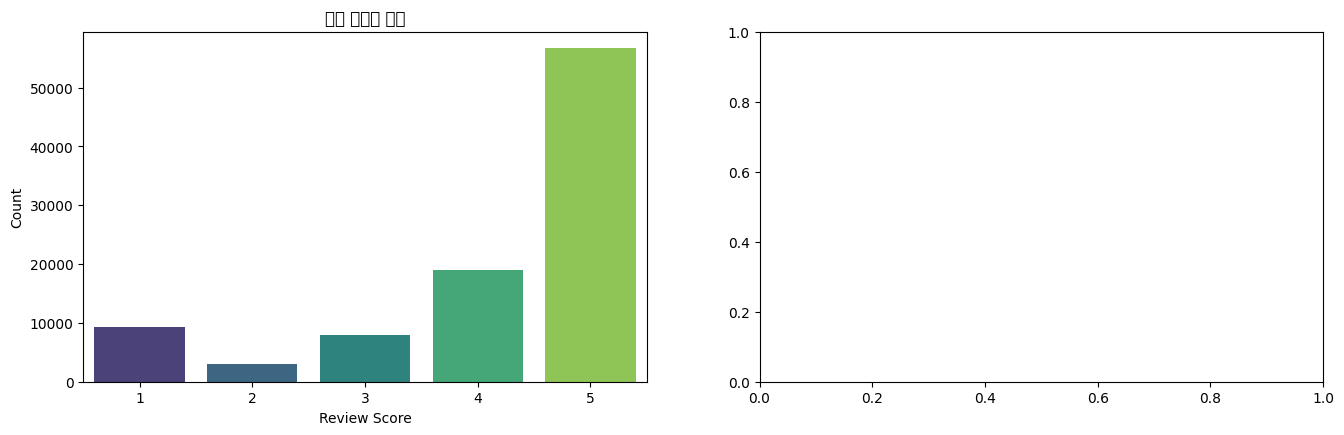

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 및 마이너스 기호 깨짐 방지 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 1. 데이터 기본 정보 및 결측치 확인
print("=== 데이터 형태 ===")
print(df.shape)
print("\n=== 결측치 현황 ===")
missing_vals = df.isnull().sum()
print(missing_vals[missing_vals > 0])

# 2. 주요 수치형 변수 요약 통계량
print("\n=== 주요 수치형 변수 요약 통계 ===")
num_cols = ['price', 'freight_value', 'review_score', 'delivery_days', 'dispatch_days', 'delay_days']
# print(df[num_cols].describe().round(2))

# --- 시각화 ---
fig = plt.figure(figsize=(16, 10))

# [그래프 1] 리뷰 스코어 분포
ax1 = fig.add_subplot(2, 2, 1)
# 결측치를 제거하고, 남은 점수들을 int 변환
clean_reviews = df.dropna(subset=['review_score']).copy()
clean_reviews['review_score'] = clean_reviews['review_score'].astype(int)
# 그래프 그리기
sns.countplot(data=clean_reviews, x='review_score', palette='viridis', ax=ax1)
ax1.set_title('리뷰 스코어 분포')
ax1.set_xlabel('Review Score')
ax1.set_ylabel('Count')

# [그래프 2] 배송 소요일 분포 (상위 5% 극단치 제외)
ax2 = fig.add_subplot(2, 2, 2)
sns.histplot(df[df['delivery_days'] < df['delivery_days'].quantile(0.95)]['delivery_days'], bins=40, color='skyblue', kde=True, ax=ax2)
ax2.set_title('전체 배송 소요일 분포 (Top 5% 극단치 제외)')
ax2.set_xlabel('Delivery Days')

# [그래프 3] 배송 지연 일수 분포 (지연된 건만)
ax3 = fig.add_subplot(2, 2, 3)
delayed_df = df[df['delay_days'] > 0]
sns.histplot(delayed_df[delayed_df['delay_days'] < delayed_df['delay_days'].quantile(0.95)]['delay_days'], bins=40, color='salmon', kde=True, ax=ax3)
ax3.set_title('배송 지연 일수 분포 (지연 발생 건 한정)')
ax3.set_xlabel('Delay Days (양수)')

# [그래프 4] 주요 변수 간의 상관관계 히트맵
ax4 = fig.add_subplot(2, 2, 4)
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, ax=ax4)
ax4.set_title('주요 변수 상관관계 (Correlation Heatmap)')

plt.tight_layout()
plt.show()

In [ ]:
clean_reviews

NameError: name 'clean_reviews' is not defined

=== 배송 지연에 따른 리뷰 스코어 분석 결과 ===
정상/조기 배송 (0) 평균 점수: 4.29점 (데이터: 88,187건)
지연 배송 (1) 평균 점수: 2.55점 (데이터: 7,599건)
두 그룹의 평균 점수 차이: 1.74점
T-test P-value: 0.0000e+00 
=> 결론: P-value가 0.05보다 작으므로, 배송 지연 여부에 따른 리뷰 점수 차이는 통계적으로 '매우 유의미'


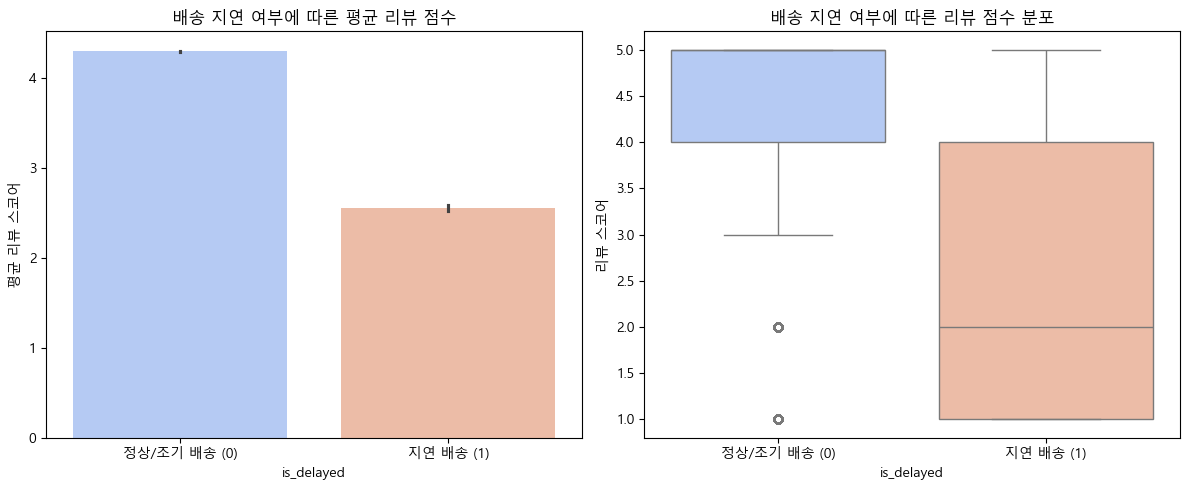

In [ ]:
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 및 마이너스 기호 깨짐 방지 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 1. 분석을 위해 결측치 제거 (리뷰 스코어가 있는 데이터만)
df_test = df.dropna(subset=['review_score', 'is_delayed']).copy()

# 리뷰 스코어를 정수형으로 변환 (안전한 계산을 위해)
df_test['review_score'] = df_test['review_score'].astype(int)

# 2. 그룹 나누기 (지연 O vs 지연 X)
delayed = df_test[df_test['is_delayed'] == 1]['review_score']
not_delayed = df_test[df_test['is_delayed'] == 0]['review_score']

# 3. T-test (통계적 검증, 분산이 다르다고 가정하고 Welch's t-test 수행)
t_stat, p_val = ttest_ind(not_delayed, delayed, equal_var=False)

print("=== 배송 지연에 따른 리뷰 스코어 분석 결과 ===")
print(f"정상/조기 배송 (0) 평균 점수: {not_delayed.mean():.2f}점 (데이터: {len(not_delayed):,}건)")
print(f"지연 배송 (1) 평균 점수: {delayed.mean():.2f}점 (데이터: {len(delayed):,}건)")
print(f"두 그룹의 평균 점수 차이: {not_delayed.mean() - delayed.mean():.2f}점")
print(f"T-test P-value: {p_val:.4e} ")
if p_val < 0.05:
    print("=> 결론: P-value가 0.05보다 작으므로, 배송 지연 여부에 따른 리뷰 점수 차이는 통계적으로 '매우 유의미'")
else:
    print("=> 결론: 통계적으로 유의미한 차이가 없음")

# 4. 시각화 (평균 막대 그래프 & 분포 박스플롯)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# [왼쪽] 평균 점수 Barplot
sns.barplot(data=df_test, x='is_delayed', y='review_score', ax=axes[0], palette='coolwarm')
axes[0].set_title('배송 지연 여부에 따른 평균 리뷰 점수')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['정상/조기 배송 (0)', '지연 배송 (1)'])
axes[0].set_ylabel('평균 리뷰 스코어')

# [오른쪽] 점수 분포 Boxplot
sns.boxplot(data=df_test, x='is_delayed', y='review_score', ax=axes[1], palette='coolwarm')
axes[1].set_title('배송 지연 여부에 따른 리뷰 점수 분포')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['정상/조기 배송 (0)', '지연 배송 (1)'])
axes[1].set_ylabel('리뷰 스코어')

plt.tight_layout()
plt.show()

=== 지연 여부에 따른 판매자 출고 시간 분석 ===
정상/조기 배송 건의 평균 출고 시간: 3.00일
지연 배송 건의 평균 출고 시간: 5.84일
차이: 지연된 주문은 평균적으로 2.85일 더 늦게 출고됨
T-test P-value: 5.0576e-249


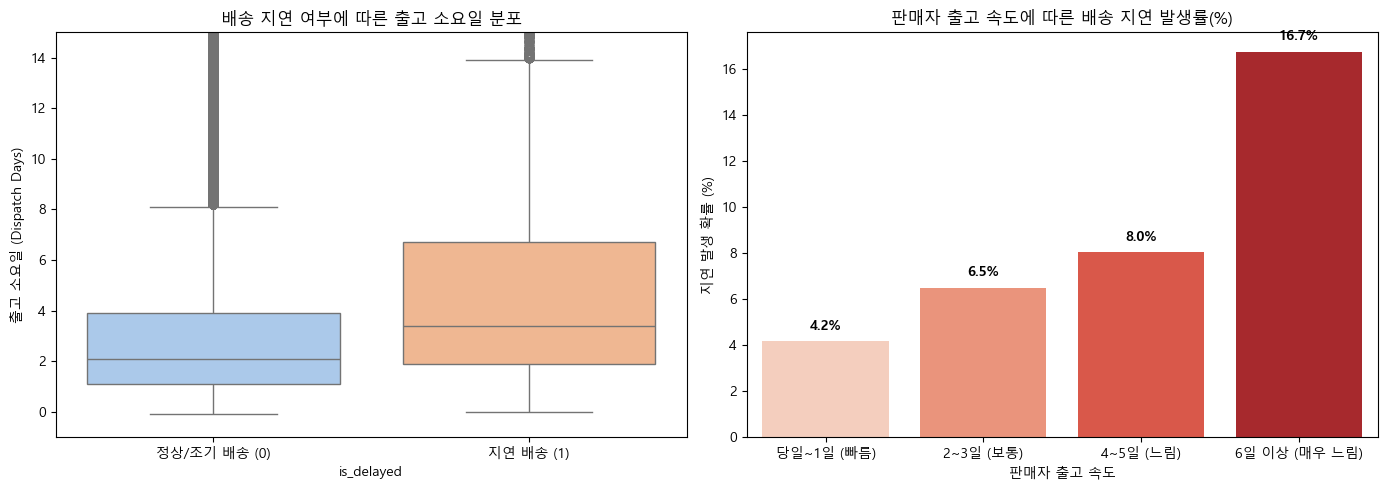

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

# 한글 폰트 및 마이너스 기호 깨짐 방지 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 1. 결측치 제거 (분석에 필요한 컬럼만)
df_analysis = df.dropna(subset=['dispatch_days', 'is_delayed']).copy()

# 2. 지연 여부에 따른 평균 출고 소요일 비교 (T-test)
delayed_dispatch = df_analysis[df_analysis['is_delayed'] == 1]['dispatch_days']
not_delayed_dispatch = df_analysis[df_analysis['is_delayed'] == 0]['dispatch_days']

t_stat, p_val = ttest_ind(not_delayed_dispatch, delayed_dispatch, equal_var=False)
    # 분산이 다르다는 것을 전제로 진행하는 웰치스 t검정

print("=== 지연 여부에 따른 판매자 출고 시간 분석 ===")
print(f"정상/조기 배송 건의 평균 출고 시간: {not_delayed_dispatch.mean():.2f}일")
print(f"지연 배송 건의 평균 출고 시간: {delayed_dispatch.mean():.2f}일")
print(f"차이: 지연된 주문은 평균적으로 {delayed_dispatch.mean() - not_delayed_dispatch.mean():.2f}일 더 늦게 출고됨")
print(f"T-test P-value: {p_val:.4e}")

# 3. 출고 소요일 구간(카테고리)화 하여 지연 발생 확률(Delay Rate) 계산
# 구간 설정: 0~1일(빠름), 2~3일(보통), 4~5일(느림), 6일 이상(매우 느림)
bins = [-np.inf, 1, 3, 5, np.inf]
labels = ['당일~1일 (빠름)', '2~3일 (보통)', '4~5일 (느림)', '6일 이상 (매우 느림)']
df_analysis['dispatch_speed'] = pd.cut(df_analysis['dispatch_days'], bins=bins, labels=labels)

# 구간별 지연율 계산 (지연된 건수 / 전체 건수 * 100)
delay_rate = df_analysis.groupby('dispatch_speed')['is_delayed'].mean() * 100

# 4. 시각화 (Boxplot & Barplot)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# [왼쪽] 배송 지연 여부에 따른 출고 소요일 분포 (Boxplot)
sns.boxplot(data=df_analysis, x='is_delayed', y='dispatch_days', ax=axes[0], palette='pastel')
axes[0].set_title('배송 지연 여부에 따른 출고 소요일 분포')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['정상/조기 배송 (0)', '지연 배송 (1)'])
axes[0].set_ylabel('출고 소요일 (Dispatch Days)')
axes[0].set_ylim(-1, 15) # 극단치를 제외하고 데이터의 중심을 보기 위해 y축 제한

# [오른쪽] 출고 속도 구간별 배송 지연 발생률 (Barplot)
sns.barplot(x=delay_rate.index, y=delay_rate.values, ax=axes[1], palette='Reds')
axes[1].set_title('판매자 출고 속도에 따른 배송 지연 발생률(%)')
axes[1].set_ylabel('지연 발생 확률 (%)')
axes[1].set_xlabel('판매자 출고 속도')

# 막대 그래프 위에 퍼센트(%) 텍스트 추가
for i, v in enumerate(delay_rate.values):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 웰치스 T-test 결과
- 판매자의 출고 속도 차이에 따른 배송 지연이 발생한 것이 단순한 우연이라고 볼 확률이 거의 0%다
- 즉, 판매자가 물건을 늦게 보내면, 최종 배송도 무조건 지연된다

In [ ]:
import pandas as pd

# state, city 수 확인
num_unique_cities = df['customer_city'].nunique()
num_unique_states = df['customer_state'].nunique()

print(f"=== 고유 지역 개수 ===")
print(f"총 고유 도시(City) 수: {num_unique_cities:,}개")
print(f"총 고유 주(State) 수: {num_unique_states:,}개")

# 상위 5개, 하위 5개
print("\n=== 가장 주문이 많은 주(State) Top 5 ===")
print(df['customer_state'].value_counts().head())

print("\n=== 가장 주문이 적은 주(State) Bottom 5 ===")
print(df['customer_state'].value_counts().tail())

=== 고유 지역 개수 ===
총 고유 도시(City) 수: 4,085개
총 고유 주(State) 수: 27개

=== 가장 주문이 많은 주(State) Top 5 ===
customer_state
SP    40474
RJ    12347
MG    11346
RS     5341
PR     4923
Name: count, dtype: int64

=== 가장 주문이 적은 주(State) Bottom 5 ===
customer_state
RO    243
AM    145
AC     80
AP     67
RR     41
Name: count, dtype: int64


In [ ]:
print("\n=== 가장 주문이 많은 도시(City) Top 5 ===")
print(df['customer_city'].value_counts().head())

print("\n=== 가장 주문이 적은 도시(City) Bottom 5 ===")
print(df['customer_city'].value_counts().tail())


=== 가장 주문이 많은 도시(City) Top 5 ===
customer_city
sao paulo         15038
rio de janeiro     6599
belo horizonte     2695
brasilia           2071
curitiba           1489
Name: count, dtype: int64

=== 가장 주문이 적은 도시(City) Bottom 5 ===
customer_city
pacuja              1
umburanas           1
messias targino     1
campo do tenente    1
nova vicosa         1
Name: count, dtype: int64


=== 배송 지연율 최악의 지역 Top 5 (리스크 지역) ===
   customer_state  delay_rate  avg_review_score  total_orders
1              AL   23.350254          3.852792           394
9              MA   19.127989          3.833333           711
16             PI   15.923567          3.993631           471
5              CE   15.172956          3.941038          1272
24             SE   14.970060          3.907186           334

=== 배송 지연율 최우수 지역 Top 5 ===
   customer_state  delay_rate  avg_review_score  total_orders
25             SP    5.769517          4.246865         40246
10             MG    5.453578          4.193225         11277
17             PR    4.918367          4.239592          4900
2              AM    4.166667          4.243056           144
20             RO    2.892562          4.165289           242


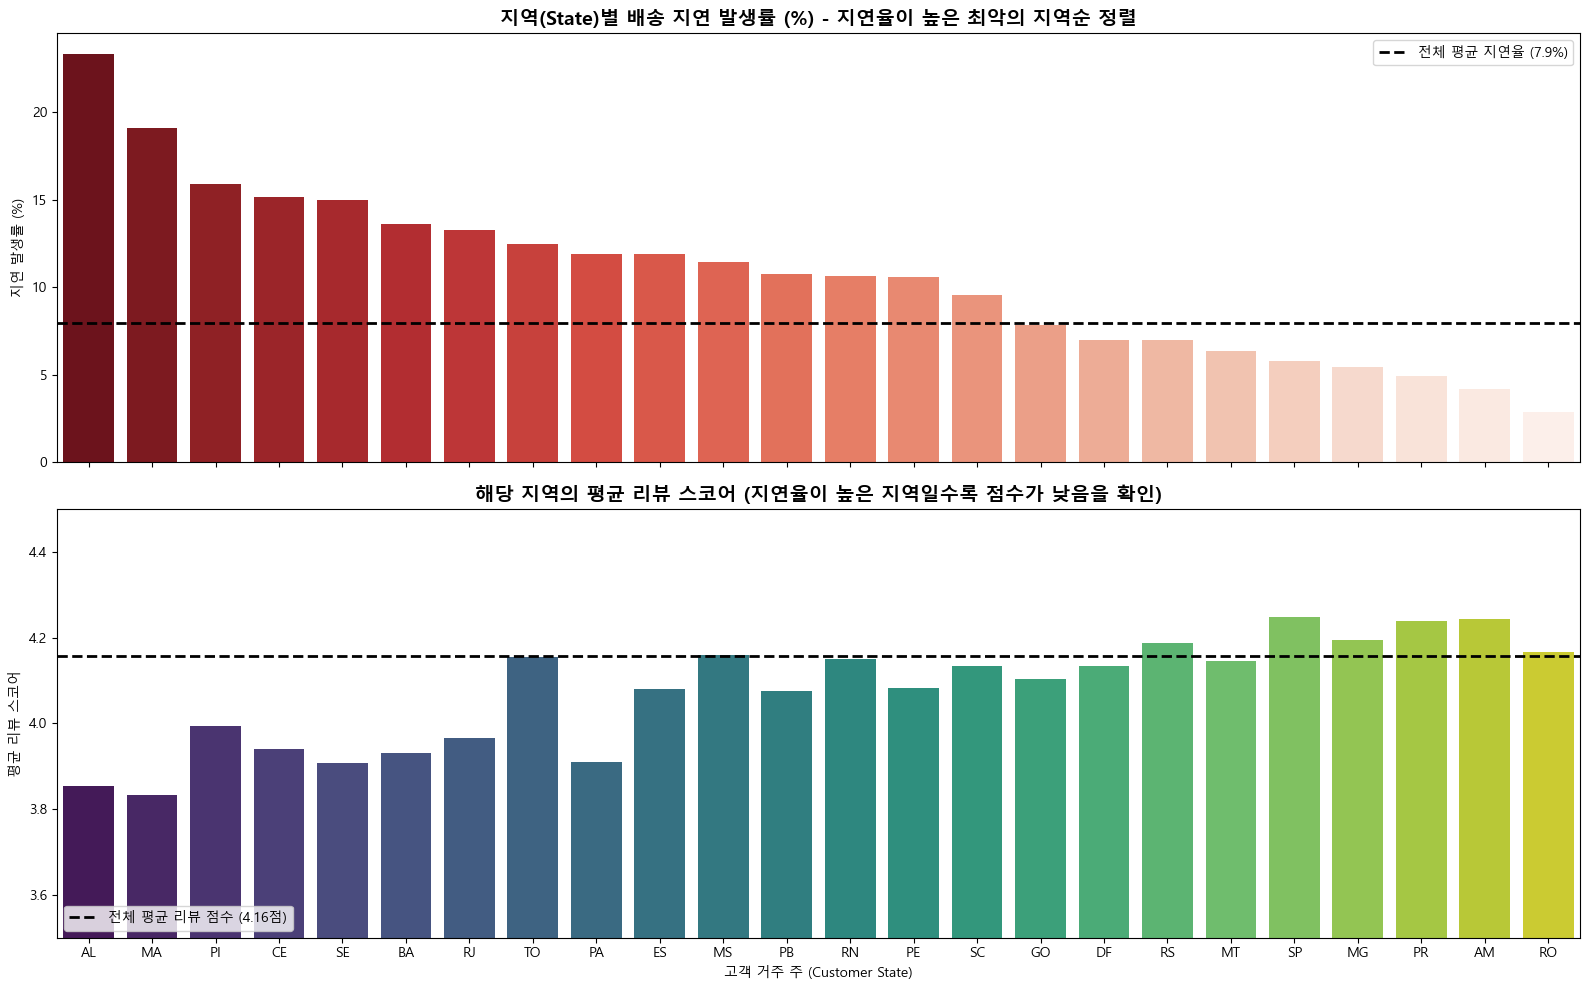

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 및 마이너스 기호 깨짐 방지 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 1. 데이터 준비 및 전처리 (주문 건수가 너무 적은 노이즈 지역 필터링)
df_clean = df.dropna(subset=['review_score', 'is_delayed', 'customer_state']).copy()

# 지역별 통계 계산
state_stats = df_clean.groupby('customer_state').agg(
    total_orders=('order_id', 'count'),
    delay_rate=('is_delayed', lambda x: x.mean() * 100),    # 지연율(%)
    avg_review_score=('review_score', 'mean')               # 평균 리뷰 점수
).reset_index()

# 데이터 신뢰성을 위해 주문 건수 100건 이상인 지역(State)만 분석
state_stats = state_stats[state_stats['total_orders'] > 100]

# 지연율이 높은 순서대로(내림차순) 정렬 
state_stats_sorted = state_stats.sort_values(by='delay_rate', ascending=False)

# 2. 결과 출력 (Top 5 최악 vs 최고 지역)
print("=== 배송 지연율 최악의 지역 Top 5 (리스크 지역) ===")
print(state_stats_sorted[['customer_state', 'delay_rate', 'avg_review_score', 'total_orders']].head())
print("\n=== 배송 지연율 최우수 지역 Top 5 ===")
print(state_stats_sorted[['customer_state', 'delay_rate', 'avg_review_score', 'total_orders']].tail())

# 3. 시각화 (두 개의 막대 그래프를 위아래로 나란히 배치)
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# 전체 평균 계산 (비교 기준선용)
overall_delay_rate = df_clean['is_delayed'].mean() * 100
overall_review_score = df_clean['review_score'].mean()

# [위쪽 그래프] 지역별 배송 지연율 (%)
sns.barplot(data=state_stats_sorted, x='customer_state', y='delay_rate', ax=axes[0], palette='Reds_r')
axes[0].set_title('지역(State)별 배송 지연 발생률 (%) - 지연율이 높은 최악의 지역순 정렬', fontsize=14, fontweight='bold')
axes[0].set_ylabel('지연 발생률 (%)')
axes[0].axhline(overall_delay_rate, color='black', linestyle='--', linewidth=2, label=f'전체 평균 지연율 ({overall_delay_rate:.1f}%)')
axes[0].legend(loc='upper right')

# [아래쪽 그래프] 지역별 평균 리뷰 스코어 (위 그래프와 동일한 x축 순서 적용)
# 순서를 맞추기 위해 order 파라미터에 state_stats_sorted의 customer_state를 지정
sns.barplot(data=state_stats_sorted, x='customer_state', y='avg_review_score', ax=axes[1], palette='viridis', order=state_stats_sorted['customer_state'])
axes[1].set_title('해당 지역의 평균 리뷰 스코어 (지연율이 높은 지역일수록 점수가 낮음을 확인)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('평균 리뷰 스코어')
axes[1].set_xlabel('고객 거주 주 (Customer State)')
axes[1].set_ylim(3.5, 4.5) # 점수 차이를 더 명확하게 보기 위해 y축 범위 조정
axes[1].axhline(overall_review_score, color='black', linestyle='--', linewidth=2, label=f'전체 평균 리뷰 점수 ({overall_review_score:.2f}점)')
axes[1].legend(loc='lower left')

plt.tight_layout()
plt.show()